# 🎯 Optimización con Optuna — XGBoost — 4 herramientas

## Qué hace Optuna
Busca automáticamente los mejores hiperparámetros. En vez de poner n_estimators=100 a ojo, prueba decenas de combinaciones y se queda con la que mejor F1 macro da.

## Cómo se evita hacer trampa (fuga del test)
El test NO se toca durante la búsqueda. Se parte el train en train_opt (80%) y val (20%). Optuna optimiza mirando solo la validación. Al final se reentrena con todo el train y se evalúa una única vez sobre el test.

## Configuración
- **GPU activada** (`device='cuda'`). Sin GPU esto tardaría horas. En haruhi hay A100.
- `N_TRIALS = 30` combinaciones por herramienta (ajustable).
- Espacio de búsqueda: n_estimators, max_depth, learning_rate, subsample, colsample_bytree, min_child_weight, gamma, reg_alpha, reg_lambda.

## Salidas
Mejores hiperparámetros por herramienta, tabla comparativa (con tiempos), matrices de confusión y comparación con el XGBoost básico.

**Si no tienes Optuna:** `pip install optuna`

**Run All y listo.**

> ⚙️ **Versión para portátil (sin GPU).** N_TRIALS=10 para que sea rápido, modelos con n_jobs=4 para no saturar el portátil. Si más adelante usas un equipo más potente, puedes subir N_TRIALS a 30 y n_jobs a -1.

In [1]:
# ============================================================
# CELDA 0 — IMPORTS Y CONFIGURACIÓN
# ============================================================
import pandas as pd
import numpy as np
import time
import gc
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

import optuna
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, recall_score, precision_score,
                              f1_score, confusion_matrix)

import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)  # menos ruido

BASE_IN = Path('/home/miguel/Escritorio/TFM/TFM_Miguel/BaseDatos')

CLASES = ['BenignTraffic', 'DictionaryBruteForce', 'Recon', 'Mirai',
          'Spoofing', 'DoS', 'DDoS', 'Web']
HERRAMIENTAS = ['CIC', 'Nemea', 'Tstat', 'Tshark']

SEED = 42
N_TRIALS = 100        # nº de combinaciones que prueba Optuna por herramienta
USAR_GPU = False      # device='cuda'. Pon False si no hay GPU (será MUY lento)

print(f'Optuna trials por herramienta: {N_TRIALS}')
print(f'GPU: {USAR_GPU}')

Optuna trials por herramienta: 100
GPU: False


/home/miguel/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ============================================================
# CELDA 1 — FUNCIÓN cargar_datos (idéntica a la del notebook RF)
# Devuelve (X, y) listos para entrenar, con las mismas reglas de
# filtrado: solo columnas comunes y eliminando sospechosas de fuga.
# ============================================================

def cargar_datos(herramienta, usar_solo_columnas_comunes=True, eliminar_sospechosas=True):
    dfs_por_clase = {}
    columnas_por_clase = {}

    for clase in CLASES:
        ruta = BASE_IN / clase / f'{herramienta}.csv'
        df_tmp = pd.read_csv(ruta, low_memory=False)
        dfs_por_clase[clase] = df_tmp
        columnas_por_clase[clase] = list(df_tmp.columns)

    print('\n' + '='*80)
    print(f'CARGA — {herramienta}')
    print('='*80)

    for clase in CLASES:
        df_tmp = dfs_por_clase[clase]
        print(f'{clase:<25} {df_tmp.shape[0]:,} filas x {df_tmp.shape[1]} columnas')

    conjuntos = [set(columnas_por_clase[clase]) for clase in CLASES]
    columnas_comunes_set = set.intersection(*conjuntos)
    columnas_union_set   = set.union(*conjuntos)

    if usar_solo_columnas_comunes:
        columnas_base = [c for c in columnas_por_clase[CLASES[0]] if c in columnas_comunes_set]
    else:
        columnas_base = sorted(columnas_union_set)

    patrones_fuga = [
        'label', 'etiqueta', 'class', 'attack', 'category', 'subtipo',
        'archivo', 'file', 'pcap',
        'flow_id', 'macaddr', 'mac', 'src_mac', 'dst_mac',
        'fqdn', 'sni', 'scn', 'dns_rslv', 'tls_sesid', 'npnalpn', 'alpn',
        'first_abs', 'req_tm', 'res_tm', 'handshaket', 'appdatat',
    ]

    columnas_id_exactas = {'id', 'ID', 'Flow ID', 'FLOW_ID', 'flow_id', 'uint64 FLOW_ID'}

    columnas_temporales_peligrosas_exactas = {
        'time* DBI_BRST_TIME_START', 'time* DBI_BRST_TIME_STOP',
        'time* SBI_BRST_TIME_START', 'time* SBI_BRST_TIME_STOP',
        'last', 'req_tm', 'res_tm', 's_first_abs',
        'c_first', 's_first', 'c_last', 's_last',
        'c_first_ack', 's_first_ack',
        'c_last_handshakeT', 's_last_handshakeT',
        'c_appdataT', 's_appdataT',
    }

    columnas_sospechosas = []
    if eliminar_sospechosas:
        for col in columnas_base:
            col_lower = col.lower()
            es_sospechosa_por_patron = any(p in col_lower for p in patrones_fuga)
            es_id = col in columnas_id_exactas or col_lower in columnas_id_exactas
            es_temporal_peligrosa = (
                col in columnas_temporales_peligrosas_exactas
                or col_lower in columnas_temporales_peligrosas_exactas
                or col_lower.startswith('time_ppi_pkt_times_')
            )
            if es_sospechosa_por_patron or es_id or es_temporal_peligrosa:
                columnas_sospechosas.append(col)

    if columnas_sospechosas:
        print(f'\n[{herramienta}] Columnas eliminadas por posible fuga directa: {len(columnas_sospechosas)}')

    columnas_finales = [c for c in columnas_base if c not in columnas_sospechosas]
    print(f'[{herramienta}] Columnas finales antes de concatenar: {len(columnas_finales)}')

    dfs = []
    for clase in CLASES:
        df_tmp = dfs_por_clase[clase][columnas_finales].copy()
        df_tmp['Label_Modelo'] = clase
        dfs.append(df_tmp)

    df = pd.concat(dfs, ignore_index=True, sort=False)
    y = df['Label_Modelo']
    X = df.drop(columns=['Label_Modelo'])

    cols_obj = X.select_dtypes(include=['object']).columns.tolist()
    if cols_obj:
        print(f'[{herramienta}] Columnas object codificadas con LabelEncoder: {len(cols_obj)}')
    for col in cols_obj:
        X[col] = X[col].fillna('__missing__').astype(str)
        X[col] = LabelEncoder().fit_transform(X[col])

    X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

    cols_constantes = [c for c in X.columns if X[c].nunique(dropna=False) <= 1]
    if cols_constantes:
        print(f'[{herramienta}] Columnas constantes eliminadas tras concatenar: {len(cols_constantes)}')
        X = X.drop(columns=cols_constantes)

    print(f'[{herramienta}] Shape final X: {X.shape}')
    return X, y

In [3]:
# ============================================================
# CELDA 2 — OPTIMIZACIÓN CON OPTUNA Y EVALUACIÓN FINAL
# ============================================================

def optimizar_y_evaluar_xgb(X, y, herramienta, n_trials=N_TRIALS):
    # 1) Codificar y
    le_y = LabelEncoder()
    y_enc = le_y.fit_transform(y)
    nombres_clase = list(le_y.classes_)

    # 2) Split test (no se toca durante la búsqueda)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_enc, test_size=0.2, random_state=SEED, stratify=y_enc
    )
    # 3) Dentro del train, separar validación para Optuna
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train, test_size=0.2, random_state=SEED, stratify=y_train
    )

    device = 'cuda' if USAR_GPU else 'cpu'

    # 4) Función objetivo: Optuna la llama una vez por combinación
    def objetivo(trial):
        params = {
            'n_estimators':     trial.suggest_int('n_estimators', 100, 600),
            'max_depth':        trial.suggest_int('max_depth', 3, 12),
            'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'gamma':            trial.suggest_float('gamma', 0.0, 5.0),
            'reg_alpha':        trial.suggest_float('reg_alpha', 0.0, 5.0),
            'reg_lambda':       trial.suggest_float('reg_lambda', 0.0, 5.0),
        }
        modelo = XGBClassifier(
            **params, tree_method='hist', device=device,
            random_state=SEED, n_jobs=4, eval_metric='mlogloss', verbosity=0
        )
        modelo.fit(X_tr, y_tr)
        pred_val = modelo.predict(X_val)
        return f1_score(y_val, pred_val, average='macro')

    # 5) Lanzar la búsqueda
    print(f'\n[{herramienta}] Optimizando ({n_trials} trials)...')
    t0 = time.time()
    estudio = optuna.create_study(direction='maximize',
                                  sampler=optuna.samplers.TPESampler(seed=SEED))
    estudio.optimize(objetivo, n_trials=n_trials)
    t_opt = time.time() - t0

    mejores = estudio.best_params
    print(f'[{herramienta}] Búsqueda completada en {t_opt:.1f}s')
    print(f'[{herramienta}] Mejor F1 (validación): {estudio.best_value:.4f}')
    print(f'[{herramienta}] Mejores hiperparámetros:')
    for k, v in mejores.items():
        print(f'      {k}: {v}')

    # 6) Reentrenar con TODO el train usando los mejores params, evaluar en test
    modelo_final = XGBClassifier(
        **mejores, tree_method='hist', device=device,
        random_state=SEED, n_jobs=4, eval_metric='mlogloss', verbosity=0
    )
    t0 = time.time()
    modelo_final.fit(X_train, y_train)
    t_train = time.time() - t0

    t0 = time.time()
    y_pred = modelo_final.predict(X_test)
    t_pred = time.time() - t0

    n_test = len(X_test)
    metricas = {
        'Herramienta':      herramienta,
        'N features':       X.shape[1],
        'Accuracy':         accuracy_score(y_test, y_pred),
        'F1 macro':         f1_score(y_test, y_pred, average='macro'),
        'Recall macro':     recall_score(y_test, y_pred, average='macro'),
        'Precision macro':  precision_score(y_test, y_pred, average='macro'),
        'Tiempo opt (s)':   t_opt,
        'Tiempo train (s)': t_train,
        'Tiempo pred (s)':  t_pred,
        'Pred us/muestra':  (t_pred / n_test) * 1e6,
    }
    cm = confusion_matrix(y_test, y_pred, labels=list(range(len(nombres_clase))))

    print(f'[{herramienta}] TEST -> Accuracy: {metricas["Accuracy"]:.4f}  F1 macro: {metricas["F1 macro"]:.4f}')

    return metricas, cm, nombres_clase, mejores

In [4]:
# ============================================================
# CELDA 3 — BUCLE PRINCIPAL: las 4 herramientas
# ============================================================

resultados = []
matrices_dict = {}
nombres_dict = {}
params_dict = {}

for herr in HERRAMIENTAS:
    print('\n' + '#'*80)
    print(f'#  PROCESANDO {herr}')
    print('#'*80)

    X, y = cargar_datos(herr, usar_solo_columnas_comunes=True, eliminar_sospechosas=True)
    metricas, cm, nombres, mejores = optimizar_y_evaluar_xgb(X, y, herr)

    resultados.append(metricas)
    matrices_dict[herr] = cm
    nombres_dict[herr] = nombres
    params_dict[herr] = mejores

    del X, y
    gc.collect()


################################################################################
#  PROCESANDO CIC
################################################################################

CARGA — CIC
BenignTraffic             3,481 filas x 71 columnas
DictionaryBruteForce      3,481 filas x 71 columnas
Recon                     3,481 filas x 71 columnas
Mirai                     3,481 filas x 71 columnas
Spoofing                  3,481 filas x 71 columnas
DoS                       3,481 filas x 71 columnas
DDoS                      3,481 filas x 71 columnas
Web                       3,481 filas x 71 columnas

[CIC] Columnas eliminadas por posible fuga directa: 1
[CIC] Columnas finales antes de concatenar: 70
[CIC] Columnas constantes eliminadas tras concatenar: 1
[CIC] Shape final X: (27848, 69)

[CIC] Optimizando (100 trials)...
[CIC] Búsqueda completada en 2243.3s
[CIC] Mejor F1 (validación): 0.7307
[CIC] Mejores hiperparámetros:
      n_estimators: 417
      max_depth: 4
      learning_ra

In [5]:
# ============================================================
# CELDA 4 — TABLA COMPARATIVA FINAL
# ============================================================

df_res = pd.DataFrame(resultados)

print('='*120)
print('  TABLA — XGBoost optimizado con Optuna')
print('='*120)

df_show = df_res.copy()
for col in ['Accuracy', 'F1 macro', 'Recall macro', 'Precision macro']:
    df_show[col] = df_show[col].map(lambda v: f'{v:.4f}')
for col in ['Tiempo opt (s)', 'Tiempo train (s)', 'Tiempo pred (s)']:
    df_show[col] = df_show[col].map(lambda v: f'{v:.1f}')
df_show['Pred us/muestra'] = df_show['Pred us/muestra'].map(lambda v: f'{v:.1f}')

print(df_show.to_string(index=False))

print('\n' + '='*120)
print('  COMPARACIÓN F1 macro: XGBoost básico vs XGBoost+Optuna')
print('='*120)
print('  Herramienta   Básico    Optuna    Mejora')
basico = {'CIC': 0.7389, 'Nemea': 0.5826, 'Tstat': 0.6272, 'Tshark': 0.7550}
for r in resultados:
    h = r['Herramienta']
    b = basico[h]
    o = r['F1 macro']
    print(f'  {h:<12} {b:.4f}    {o:.4f}    {o-b:+.4f}')

  TABLA — XGBoost optimizado con Optuna
Herramienta  N features Accuracy F1 macro Recall macro Precision macro Tiempo opt (s) Tiempo train (s) Tiempo pred (s) Pred us/muestra
        CIC          69   0.7400   0.7393       0.7400          0.7441         2243.3             28.1             0.3            57.0
      Nemea         148   0.5989   0.5834       0.5989          0.6225         2200.8             40.3             0.6           111.9
      Tstat          96   0.6343   0.6301       0.6342          0.6728         1965.6             26.2             0.5            88.6
     Tshark          50   0.7564   0.7558       0.7563          0.7593         3229.7             49.2             0.7           129.1

  COMPARACIÓN F1 macro: XGBoost básico vs XGBoost+Optuna
  Herramienta   Básico    Optuna    Mejora
  CIC          0.7389    0.7393    +0.0004
  Nemea        0.5826    0.5834    +0.0008
  Tstat        0.6272    0.6301    +0.0029
  Tshark       0.7550    0.7558    +0.0008


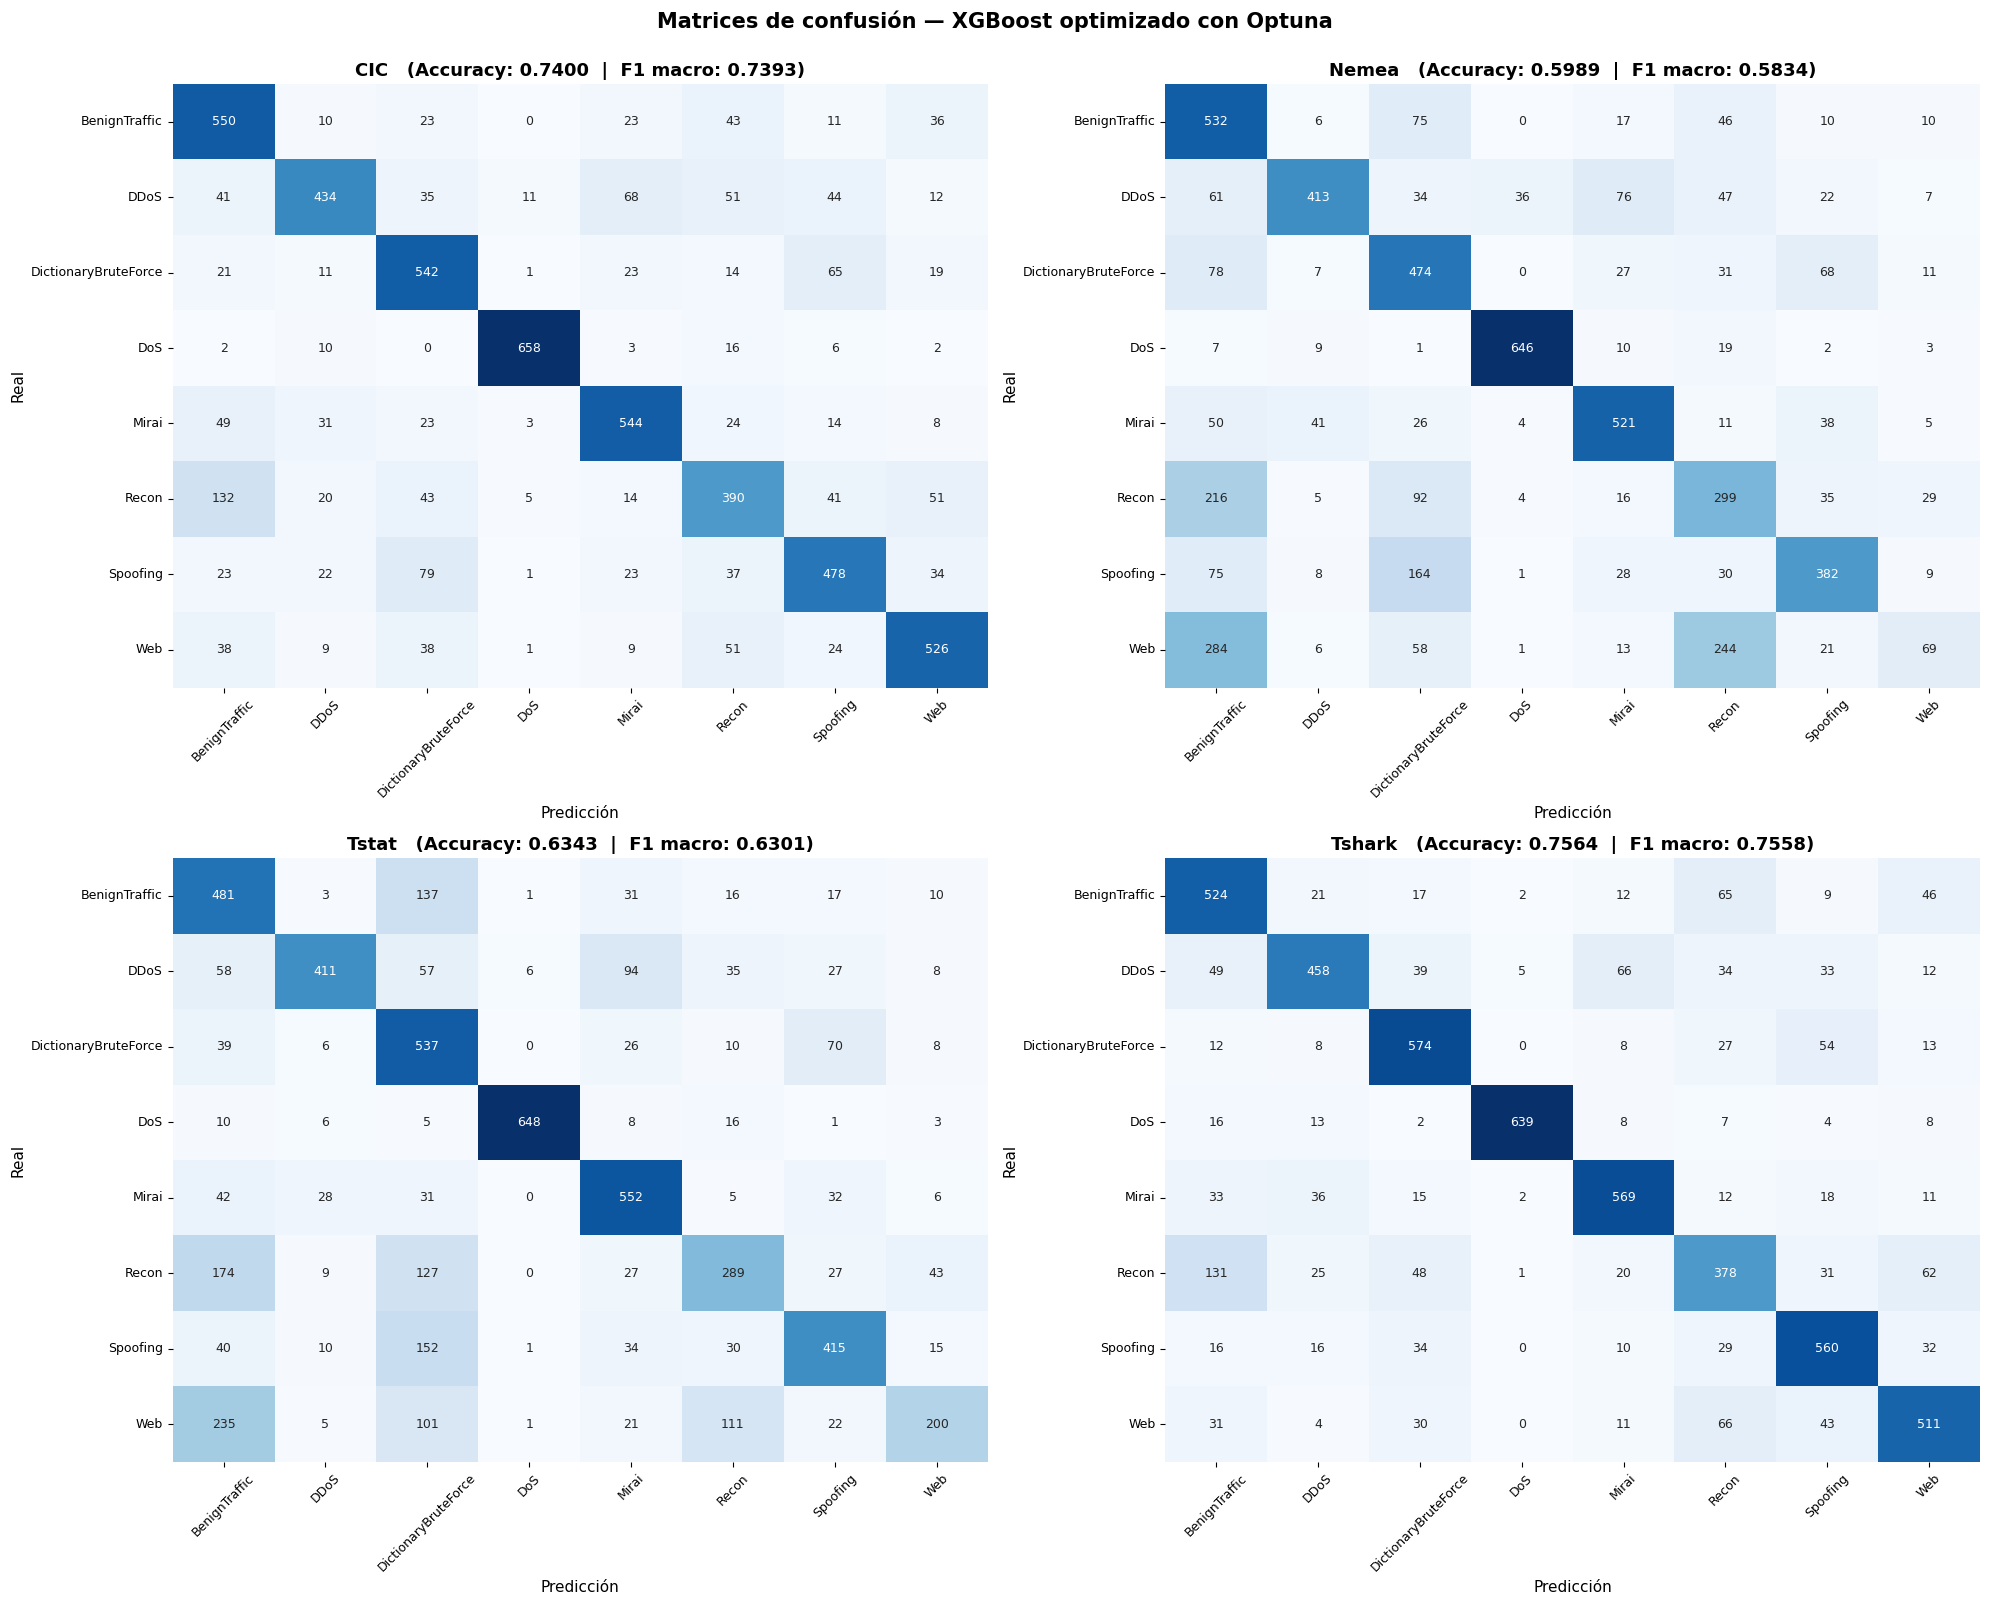

In [6]:
# ============================================================
# CELDA 5 — MATRICES DE CONFUSIÓN (grid 2×2)
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(20, 16))
axes = axes.flatten()

for i, herr in enumerate(HERRAMIENTAS):
    cm = matrices_dict[herr]
    nombres = nombres_dict[herr]
    ax = axes[i]

    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=nombres, yticklabels=nombres,
        ax=ax, cbar=False, square=False,
        annot_kws={'size': 9}
    )

    acc = next(r['Accuracy'] for r in resultados if r['Herramienta'] == herr)
    f1  = next(r['F1 macro'] for r in resultados if r['Herramienta'] == herr)
    ax.set_title(f'{herr}   (Accuracy: {acc:.4f}  |  F1 macro: {f1:.4f})', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicción', fontsize=11)
    ax.set_ylabel('Real', fontsize=11)
    ax.tick_params(axis='x', rotation=45, labelsize=9)
    ax.tick_params(axis='y', rotation=0,  labelsize=9)

plt.suptitle('Matrices de confusión — XGBoost optimizado con Optuna', fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

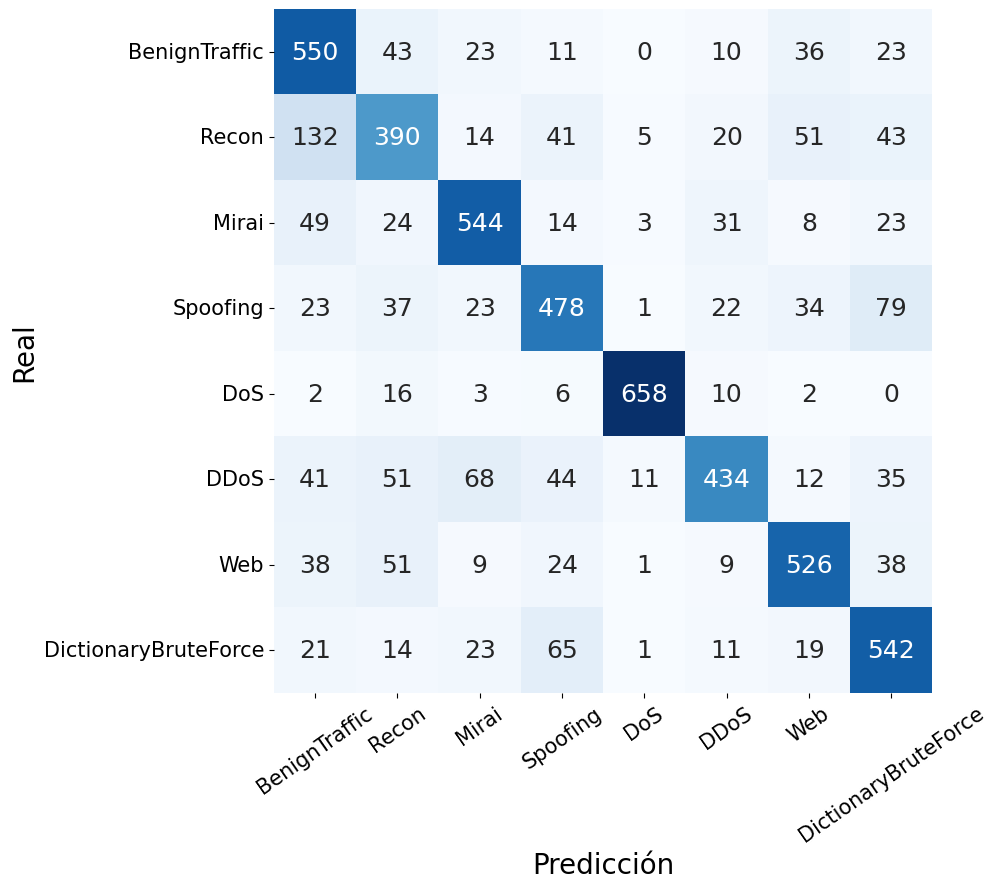

✓ Guardado: /home/miguel/Escritorio/TFM/TFM_Miguel/Figuras/MatricesConfusion/cm_xgb_optuna_CIC.pdf


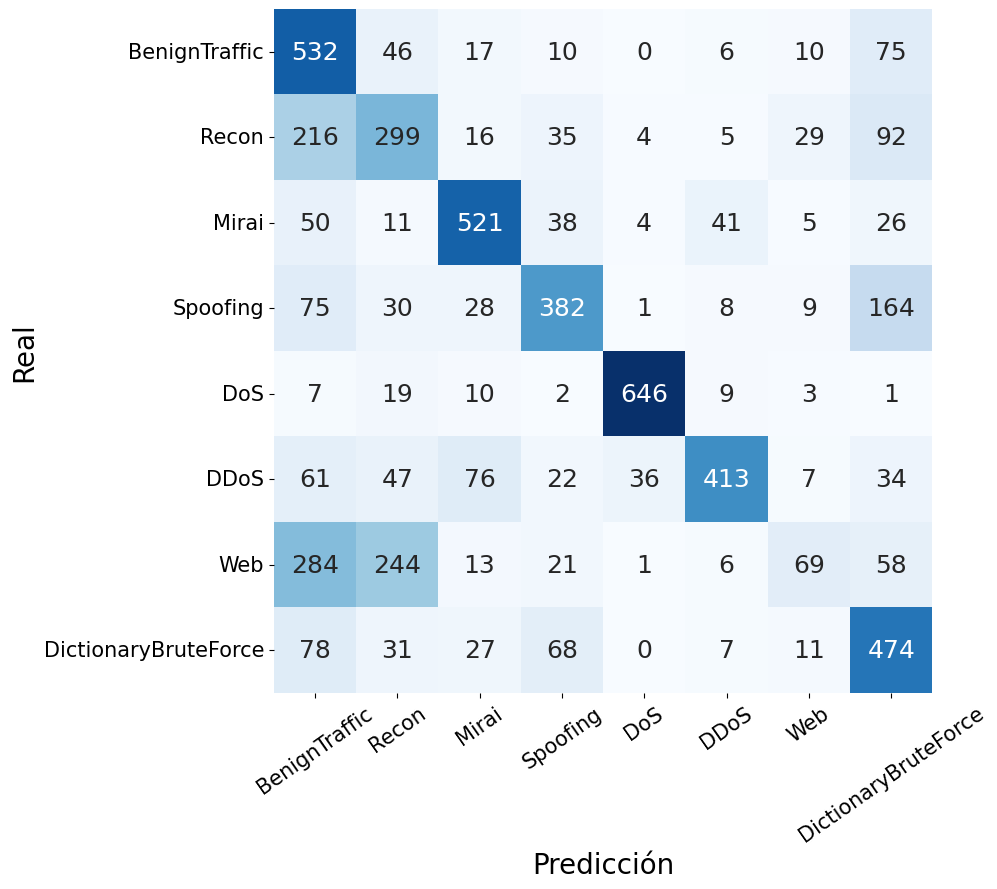

✓ Guardado: /home/miguel/Escritorio/TFM/TFM_Miguel/Figuras/MatricesConfusion/cm_xgb_optuna_Nemea.pdf


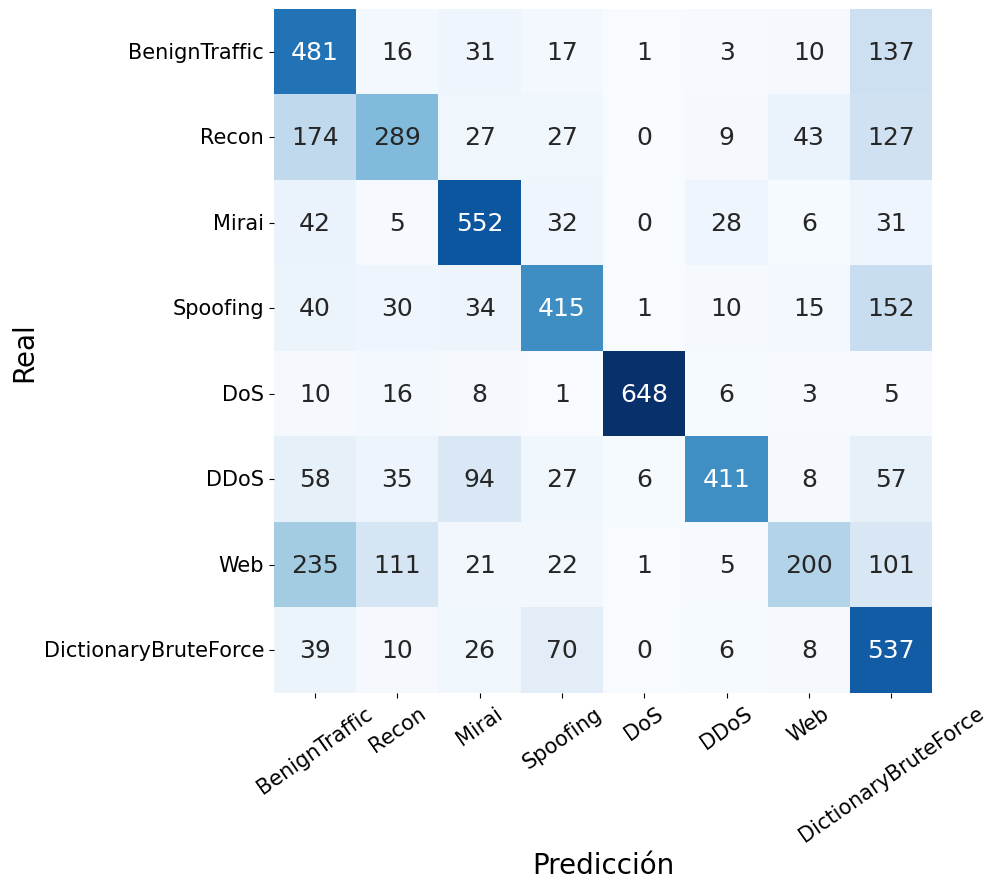

✓ Guardado: /home/miguel/Escritorio/TFM/TFM_Miguel/Figuras/MatricesConfusion/cm_xgb_optuna_Tstat.pdf


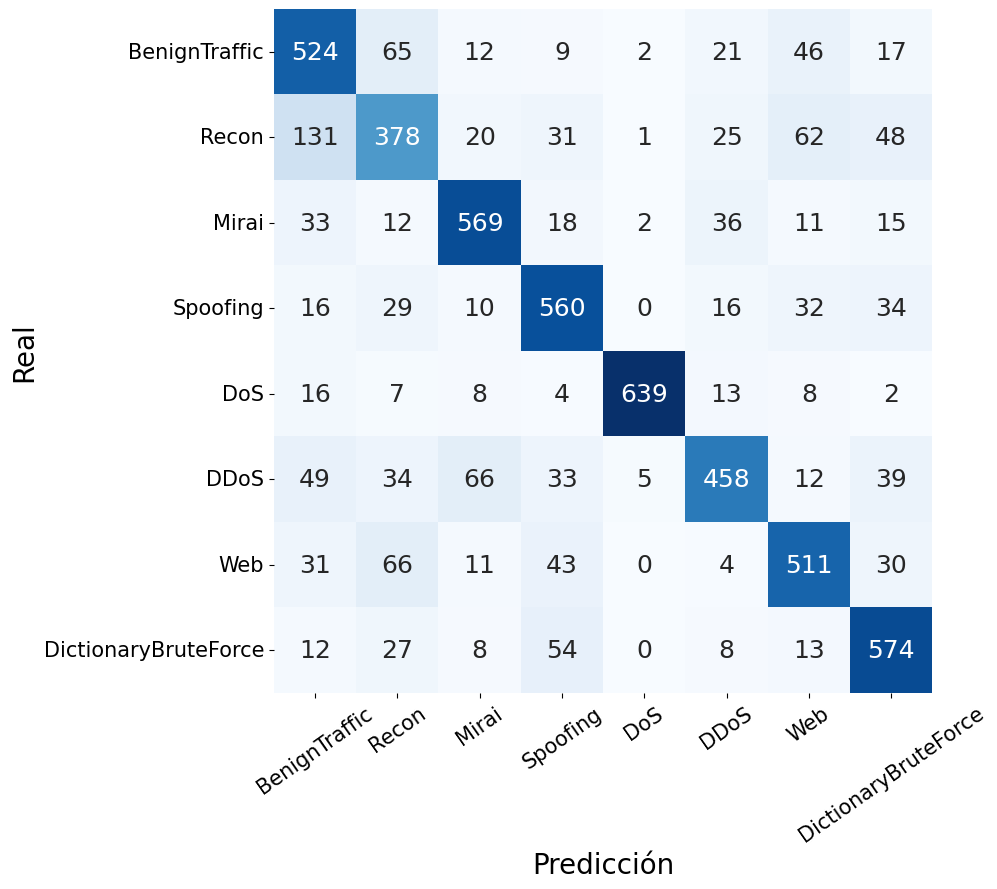

✓ Guardado: /home/miguel/Escritorio/TFM/TFM_Miguel/Figuras/MatricesConfusion/cm_xgb_optuna_Tshark.pdf


In [7]:
# ============================================================
# CELDA 6 — Matrices de confusión (4 PDF separados, uno por herramienta)
# ============================================================

RUTA_FIGURAS = Path('/home/miguel/Escritorio/TFM/TFM_Miguel/Figuras/MatricesConfusion/')
RUTA_FIGURAS.mkdir(parents=True, exist_ok=True)

ORDEN_FIGURA = ['BenignTraffic', 'Recon', 'Mirai', 'Spoofing',
                'DoS', 'DDoS', 'Web', 'DictionaryBruteForce']

for herr in HERRAMIENTAS:
    cm = matrices_dict[herr]
    nombres = nombres_dict[herr]
    perm = [nombres.index(c) for c in ORDEN_FIGURA]
    cm_ordenada = cm[perm][:, perm]

    fig, ax = plt.subplots(figsize=(10, 9))
    sns.heatmap(cm_ordenada, annot=True, fmt='d', cmap='Blues',
                xticklabels=ORDEN_FIGURA, yticklabels=ORDEN_FIGURA,
                cbar=False, ax=ax, annot_kws={'size': 18})

    ax.set_xlabel('Predicción', fontsize=20)
    ax.set_ylabel('Real', fontsize=20)
    ax.tick_params(axis='x', rotation=35, labelsize=15)
    ax.tick_params(axis='y', rotation=0,  labelsize=15)

    plt.tight_layout()

    ruta_pdf = RUTA_FIGURAS / f'cm_xgb_optuna_{herr}.pdf'
    fig.savefig(ruta_pdf, format='pdf', bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print(f'✓ Guardado: {ruta_pdf}')

In [8]:
# CELDA THROUGHPUT — XGBoost + Optuna
import numpy as np

BYTES_MEDIO_FLUJO = {
    'CIC':    48,
    'Nemea':  101,
    'Tstat':  51,
    'Tshark': 206
}

print('\n' + '='*70)
print('  THROUGHPUT — XGBoost + Optuna')
print('='*70)
print(f'  {"Herramienta":10s}  {"µs/muestra":12s}  {"Flujos/s":12s}  {"Throughput (Mbps)":18s}')
print(f'  {"-"*10}  {"-"*12}  {"-"*12}  {"-"*18}')

for r in resultados:
    herr = r['Herramienta']
    us_muestra = r['Pred us/muestra']
    flujos_s = 1e6 / us_muestra
    bytes_medio = BYTES_MEDIO_FLUJO[herr]
    throughput_mbps = (flujos_s * bytes_medio * 8) / 1e6
    print(f'  {herr:10s}  {us_muestra:12.1f}  {flujos_s:12.0f}  {throughput_mbps:18.1f}')


  THROUGHPUT — XGBoost + Optuna
  Herramienta  µs/muestra    Flujos/s      Throughput (Mbps) 
  ----------  ------------  ------------  ------------------
  CIC                 57.0         17557                 6.7
  Nemea              111.9          8940                 7.2
  Tstat               88.6         11289                 4.6
  Tshark             129.1          7748                12.8
